In [1]:
from pathlib import Path
import pandas as pd

# Point directly to data folder relative to this notebook
DATA_FILE = Path.cwd().parent / "data" / "house_prices.csv"

try:
    df = pd.read_csv(DATA_FILE)
    print(f"Dataset successfully loaded from: {DATA_FILE.resolve()}\n")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
    print("--- Column Info ---")
    df.info()
    print("\n--- First 5 Rows ---")
    print(df.head())
    print("\n--- Summary Statistics ---")
    print(df.describe())
except FileNotFoundError:
    print(f"Could not locate file at {DATA_FILE.resolve()}. Check that house_prices.csv is inside Month 4/data/.")
except Exception as e:
    print(f"Unexpected error: {e}")

Dataset successfully loaded from: C:\Users\ajasl\OneDrive\Documents\Project\The Developers Arena\Month 4\data\house_prices.csv

Shape: 300 rows, 8 columns

--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Property_Type  300 non-null    object
 7   Price          300 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 18.9+ KB

--- First 5 Rows ---
  Property_ID  Area  Bedrooms  Bathrooms  Age     Location Property_Type  \
0    PROP0001  3712         4          3   36        Rural         House   
1    PROP0002  1591         4          1   35       Suburb       

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

--- Categorical Feature Categories ---
Locations: ['Rural' 'Suburb' 'City Center']
Property Types: ['House' 'Villa' 'Apartment']

--- Correlation with Price ---
Price        1.000000
Area         0.796287
Bedrooms     0.202458
Bathrooms   -0.030279
Age         -0.130781
Name: Price, dtype: float64


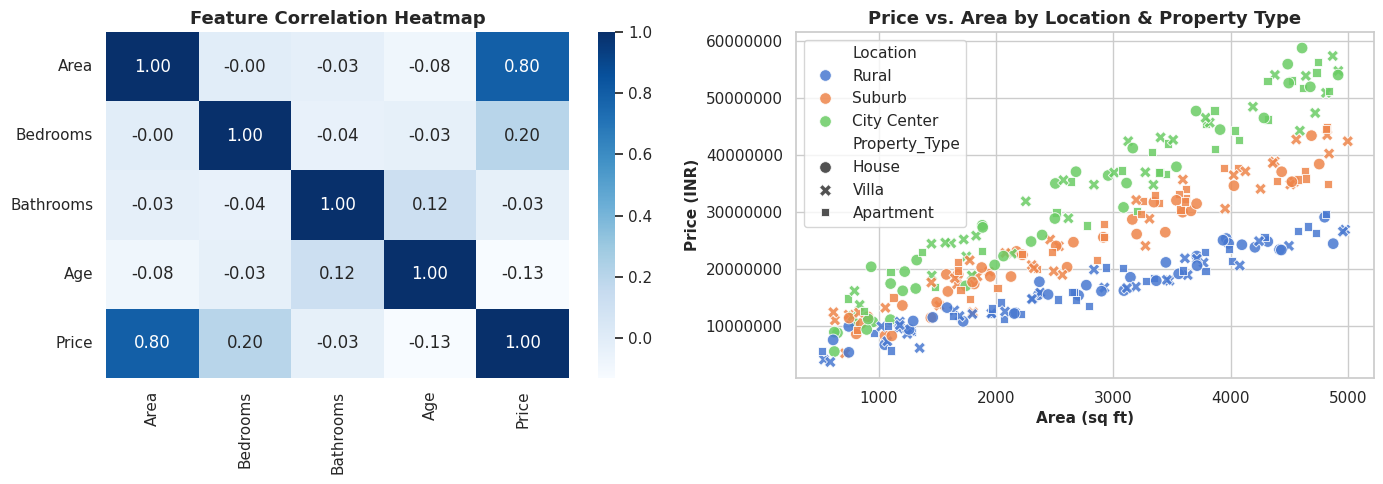

In [6]:
# Set clean visualization theme for readability
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# 1. Inspect unique values in categorical features
print("--- Categorical Feature Categories ---")
print("Locations:", df["Location"].unique())
print("Property Types:", df["Property_Type"].unique())

# 2. Compute correlation with target Price
numeric_cols = ["Area", "Bedrooms", "Bathrooms", "Age", "Price"]
corr_matrix = df[numeric_cols].corr()
print("\n--- Correlation with Price ---")
print(corr_matrix["Price"].sort_values(ascending=False))

# 3. Visualizations: Correlation Heatmap and Price vs. Area
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f", ax=axes[0], cbar=True)
axes[0].set_title("Feature Correlation Heatmap", fontsize=13, weight="bold")

# Scatter: Area vs. Price colored by Location
sns.scatterplot(
    data=df,
    x="Area",
    y="Price",
    hue="Location",
    style="Property_Type",
    s=70,
    alpha=0.85,
    ax=axes[1]
)
axes[1].set_title("Price vs. Area by Location & Property Type", fontsize=13, weight="bold")
axes[1].set_xlabel("Area (sq ft)", fontsize=11, weight="bold")
axes[1].set_ylabel("Price (INR)", fontsize=11, weight="bold")
axes[1].ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()